In [29]:
library(Seurat)
library(ggplot2)
library(patchwork)
library(dplyr)

In [34]:
scdata <- read.table(
  file = '/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/sc_expression.tsv',
  sep = '\t',
  header = TRUE,
  row.names = 1   # 关键：将第一列作为行名
)

In [4]:
scdata

,X100047181052654346224529175853339022386,X100144987682981782100923292757524648699,X100267747580756240041023704492842942950,X100380418078413692631351412383892166094,X100416591302420540942373170232872783233,X100437568120019600927652936190009214346,X100520046493178546699313517559503591662,X100542677892296141453580613270127987555,X100710098199264639646181147670539642555,X100711744188560459860855719622720771969,⋯,X99345346601115168045856425152410749974,X9943842365084414804865460677331437376,X99461758348276171282164065674893881464,X99488129778717041117129540625347059990,X99494524642456242156029918873490781817,X99504125950471062201252312391570289780,X99576957710400794105941222351708881383,X99702068459277783182220371956699162352,X99778991571303589367487716650245967462,X99975236811446463664882595554107570635
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1700022I11Rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,⋯,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.0000000
1810046K07Rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,⋯,0.0000000,1.959994,0.000000,2.785284,0.000000,0.6265323,0.0000000,0.0000000,0.000000,0.0000000
5031425F14Rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,⋯,0.0000000,0.000000,1.544658,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.0000000
5730522E02Rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,⋯,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.0000000
Acta2,2.330091,1.381474,0.000000,0.000000,0.000000,1.5294915,2.559233,0.000000,1.281749,1.1555973,⋯,0.8578376,0.000000,0.000000,0.000000,25.486650,0.6265323,1.6057280,0.0000000,0.000000,0.0000000
Adam2,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,⋯,0.8578376,0.000000,0.000000,0.000000,2.316968,0.0000000,0.0000000,0.0000000,0.000000,0.0000000
Adamts2,0.000000,1.381474,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,1.281749,0.0000000,⋯,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.5352427,0.0000000,0.000000,0.0000000
Adamts4,13.980545,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,⋯,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.0000000
Adra1b,0.000000,1.381474,3.925498,8.570366,4.280297,1.5294915,0.000000,0.000000,0.000000,0.0000000,⋯,0.0000000,1.959994,0.000000,11.141136,0.000000,0.0000000,0.0000000,0.0000000,3.599324,0.0000000


In [36]:
scdata1 <- as.matrix(scdata)

In [37]:
library(Seurat)
library(data.table)
library(Matrix)


pbmc <- CreateSeuratObject(
  counts = scdata1,
  project = "SimMerfish",
  min.cells = 3,
  min.features = 1
)

print(pbmc)

Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”


An object of class Seurat 
254 features across 4198 samples within 1 assay 
Active assay: RNA (254 features, 0 variable features)
 1 layer present: counts


In [41]:
pbmc <- NormalizeData(pbmc, normalization.method = "LogNormalize", scale.factor = 100)

Normalizing layer: counts



In [42]:
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 2000)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(pbmc), 10)

Finding variable features for layer counts



In [43]:
# 4. 执行 PCA
pbmc <- RunPCA(pbmc, features = VariableFeatures(pbmc), npcs = 50)

PC_ 1 
Positive:  Slc17a7, Satb2, Slc30a3, C1ql3, Wipf3, Syndig1, Unc5d, Prdm8, Ptprt, Col25a1 
	   Ptprk, Meis2, Nr4a1, Lamp5, Epha7, Cux2, Rgs6, Cbln2, Grm1, Npnt 
	   Grm8, Ccdc3, Otof, Cdh12, Sertm1, Ntng2, Shisa9, Ccbe1, Prr16, Dscaml1 
Negative:  Timp3, Cldn5, Flt1, Vtn, Rgs5, Bgn, Igf2, Cobll1, Plekhg3, Nr2f2 
	   Ptprm, Unc5b, Daam2, Cspg4, Gfap, Cxcl14, Pdlim5, Aqp4, Tbc1d4, Myh14 
	   Serpinf1, Cd14, Kcnj8, Sox10, Tshz2, Tmtc2, Egfr, Lama3, Pxdc1, Pdgfra 
PC_ 2 
Positive:  Cux2, Calb1, Lamp5, Otof, Ptprk, Unc5d, Slc30a3, Igfbp5, Itgb8, Timp3 
	   Sertm1, C1ql3, Prdm8, Gpc6, Flt1, Cldn5, Rgs5, Igf2, Ccbe1, Vtn 
	   Rorb, Bgn, Gfap, Ccdc3, Trp53i11, Aqp4, Cdh12, Rgs6, Camk2d, Trpc6 
Negative:  Bcl11b, Sulf2, Spon1, Rab3b, Syt6, Tox, Fezf2, Slc32a1, Sema5a, Gad1 
	   Foxp2, Prss23, Parm1, Rnf152, Grik1, Alk, Nxph1, Ano4, Lhx6, Grm8 
	   Elfn1, Plcxd3, Reln, Prss12, Ubash3b, Adra1b, Pvalb, Ptpru, Sst, Cnr1 
PC_ 3 
Positive:  Slc17a7, Fezf2, Tox, Grm8, Foxp2, Satb2, Wnt7b, Syt6, S

In [27]:
colnames(pbmc@reductions$pca@cell.embeddings)=paste0("LSI_", 1:50)

ERROR: Error in `*tmp*`@cell.embeddings: 没有适用于`@`的方法应用于类“NULL”的对象


In [21]:
write.table(pbmc@reductions$pca@cell.embeddings[,2:30], file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/spaTrio/emb.csv", sep = ",", quote = FALSE)

In [10]:
celltype_label=read.table('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/cell_type_labels.tsv',sep='\t',header = T,row.names = 1)

In [13]:
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)

Centering and scaling data matrix



In [45]:
pbmc@meta.data$cell_type=celltype_label$CellType

In [64]:
colnames(pbmc@meta.data)
head(pbmc@meta.data)

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA"

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
100047181052654346224529175853339022386,SimMerfish,179.3471,38
100144987682981782100923292757524648699,SimMerfish,125.3384,47
100267747580756240041023704492842942950,SimMerfish,97.0239,28
100380418078413692631351412383892166094,SimMerfish,130.9200,30
100416591302420540942373170232872783233,SimMerfish,124.8549,49
100437568120019600927652936190009214346,SimMerfish,296.3347,104


In [51]:
dim(pbmc)

[1]  254 4198

In [ ]:
pbmc.markers <- FindAllMarkers(pbmc, only.pos = TRUE,group.by='cell_type')

Calculating cluster Oligo



For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster VLMC

Calculating cluster Astro

Calculating cluster L4_5_IT

Calculating cluster L5_IT

Calculating cluster L2_3_IT

Calculating cluster Endo

Calculating cluster L6_IT

Calculating cluster Sst

Calculating cluster L5_ET

Calculating cluster L6_CT

Calculating cluster Peri

Calculating cluster PVM

Calculating cluster Micro

Calculating cluster SMC

Calculating cluster L5_6_NP

Calculating cluster Vip

Calculating cluster OPC

Calculating cluster Pvalb

Calculating cluster Lamp5

Calculating cluster 

In [52]:
pbmc.markers

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Opalin,5.185235e-220,6.7175106,0.730,0.042,1.317050e-217,Oligo,Opalin
Plekhg3,6.521023e-163,5.2349019,0.983,0.146,1.656340e-160,Oligo,Plekhg3
Sox10,7.864438e-153,5.3576382,0.991,0.165,1.997567e-150,Oligo,Sox10
Unc5b,3.379831e-151,5.6183642,0.974,0.160,8.584770e-149,Oligo,Unc5b
Adamts4,1.235673e-148,6.1465348,0.930,0.144,3.138610e-146,Oligo,Adamts4
Prox1,1.066731e-88,4.3143519,0.574,0.072,2.709498e-86,Oligo,Prox1
Myh14,1.099106e-59,3.3836556,0.843,0.312,2.791729e-57,Oligo,Myh14
Daam2,3.892962e-58,2.2476559,0.913,0.373,9.888123e-56,Oligo,Daam2
Enpp6,2.612318e-35,5.8262102,0.243,0.031,6.635289e-33,Oligo,Enpp6


In [71]:
write.table(pbmc.markers,file = 'makers_zztry.txt',sep='\t',quote = F)

In [72]:
stdata=readRDS('/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/Visium_FAD_1.rds')

In [73]:
stdata <- SCTransform(stdata, assay = "Spatial", verbose = FALSE)

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.




Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, m

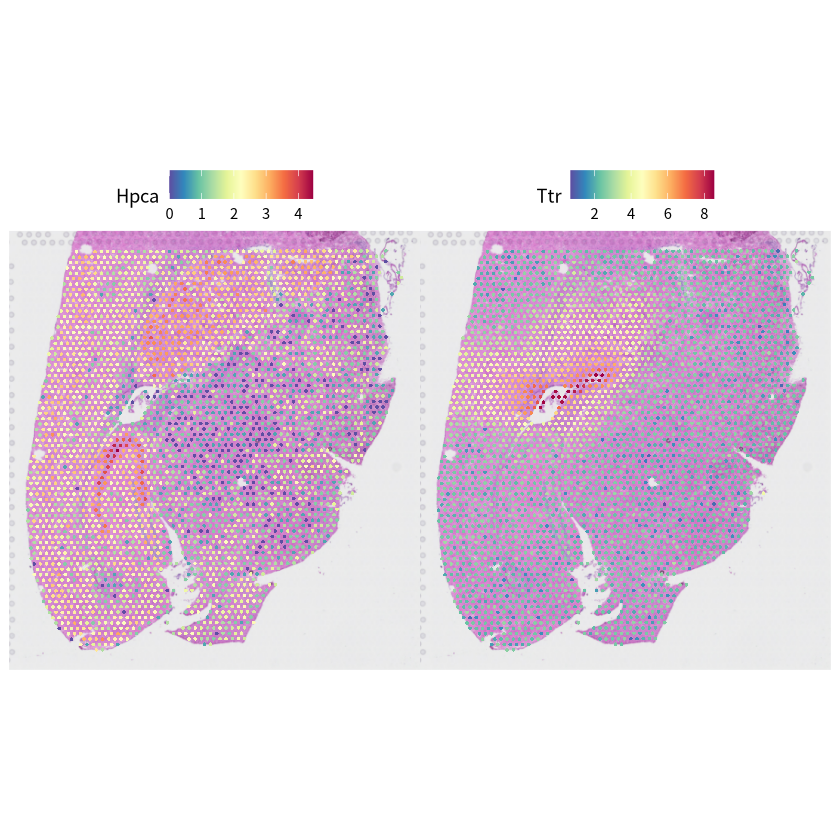

In [74]:
SpatialFeaturePlot(stdata, features = c("Hpca", "Ttr"))

In [19]:
stdata <- RunPCA(stdata, assay = "SCT", verbose = FALSE)
stdata <- FindNeighbors(stdata, reduction = "pca", dims = 1:30)
stdata <- FindClusters(stdata, verbose = FALSE)
stdata <- RunUMAP(stdata, reduction = "pca", dims = 1:30)

Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
18:15:37 UMAP embedding parameters a = 0.9922 b = 1.112

18:15:37 Read 3476 rows and found 30 numeric columns

18:15:37 Using Annoy for neighbor search, n_neighbors = 30

18:15:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:15:37 Writing NN index file to temp file /tmp/Rtmp7PCpSF/file19d8ec734f4b5

18:15:37 Searching Annoy index using 1 thread, search_k = 3000

18:15:38 Annoy recall = 100%

18:15:38 Commencing smooth kNN distance cal